In [ ]:
import pandas as pd

df = pd.read_csv("dataset/creditcard_2023.csv")  # check file
# V1-V28: Anonymized features representing various transaction attributes (e.g., time, location, etc.)
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


## Compare the mean vectors of the fraud and normal groups

Mean vector:

```
28-dimensional mean vector over all features [V1, V2, ..., V28]
```


Fraud:

$$\mu_{fraud} = [E(V_1), E(V_2), \ldots, E(V_{28})]$$

Normal:

$$\mu_{normal} = [E(V_1), E(V_2), \ldots, E(V_{28})]$$

---

### Why do we check this?

Each class is a set of points in 28-dimensional space.

If the "center" of those points differs between classes, that indicates a structural difference between fraud and normal transactions.

---

### How to calculate

With pandas it's straightforward:

```python
fraud_mean = df[df["Class"] == 1].iloc[:, 1:29].mean()
normal_mean = df[df["Class"] == 0].iloc[:, 1:29].mean()
```

(Adjust column indices to match your dataframe.)

The result: length-28 vectors for each group.


In [ ]:
import numpy as np

# Standardized mean difference (두 집단 평균 차이를 공통 표준편차로 나눈 값.)
fraud = df[df["Class"] == 1].iloc[:, 1:29]
normal = df[df["Class"] == 0].iloc[:, 1:29]

fraud_mean = fraud.mean()
normal_mean = normal.mean()
# diff vector.
# 두 클래스가 공간에서 서로 다른 위치에 있는가?를 알아보기 위한 값. 즉, “선형 분리 가능성”을 보는 첫 번째 방법
mean_diff = fraud_mean - normal_mean

fraud_std = fraud.std()
normal_std = normal.std()

n_f = len(fraud)
n_n = len(normal)

# “두 집단이 같은 분산을 가진다”는 가정 하에서 그 공통 분산을 가장 효율적으로 추정한 값
# 합동(풀링) 분산(pooled variance)은 서로 다른 표본들이 같은 모집단 분산을 공유한다고 가정할 때, 
# 각 표본 분산을 자유도(표본 크기-1)로 가중 평균해 공통 분산을 더 정확히 추정하는 방법
pooled_std = np.sqrt(
    ((n_f - 1) * fraud_std**2 + (n_n - 1) * normal_std**2)
    / (n_f + n_n - 2)
)

# 단순히 diff vector가 아니라 smd를 보는 이유 : 두 집단의 분산이 다를 수 있으므로
# raw mean diff는 “위치 차이”만 봄, SMD는 “위치 차이를 노이즈 대비 얼마나 큰지” 본다
smd = (fraud_mean - normal_mean) / pooled_std



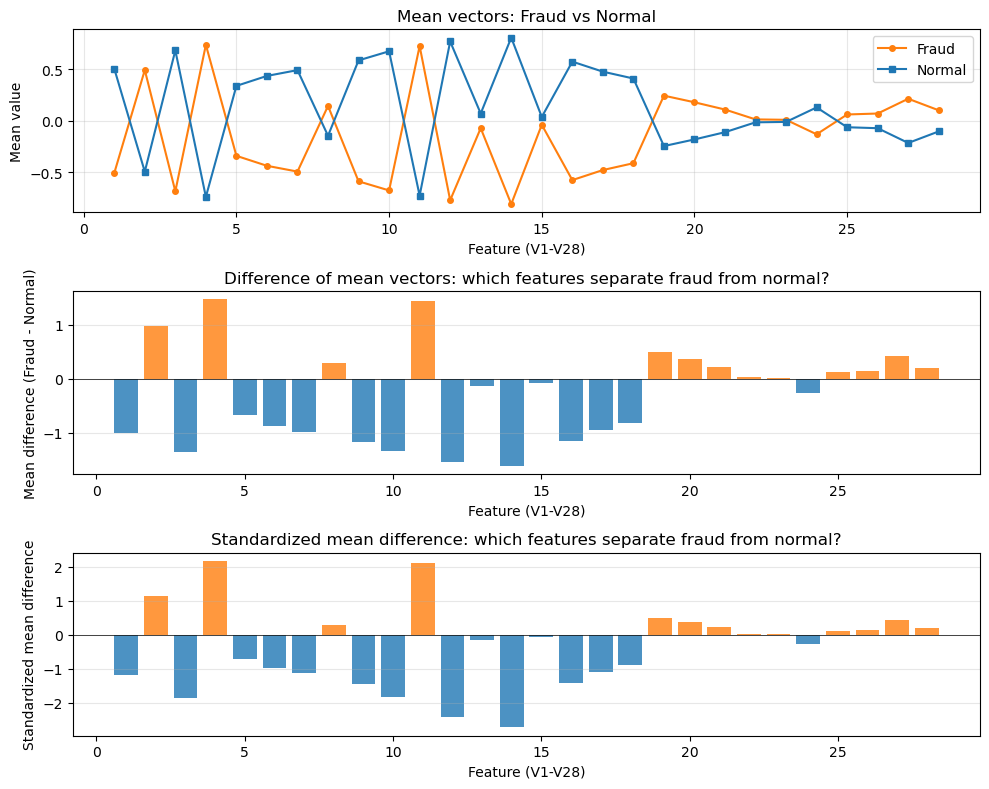

In [22]:
import matplotlib.pyplot as plt

# 1. Line plot: compare mean vectors across V1–V28 (most common way to visualize two mean vectors)
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

x = np.arange(1, 29)  # V1..V28
axes[0].plot(x, fraud_mean.values, "o-", label="Fraud", color="C1", markersize=4)
axes[0].plot(x, normal_mean.values, "s-", label="Normal", color="C0", markersize=4)
axes[0].set_xlabel("Feature (V1-V28)")
axes[0].set_ylabel("Mean value")
axes[0].set_title("Mean vectors: Fraud vs Normal")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Bar chart of difference: which dimensions separate the classes most
axes[1].bar(x, mean_diff.values, color=np.where(mean_diff.values >= 0, "C1", "C0"), alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_xlabel("Feature (V1-V28)")
axes[1].set_ylabel("Mean difference (Fraud - Normal)")
axes[1].set_title("Difference of mean vectors: which features separate fraud from normal?")
axes[1].grid(True, alpha=0.3, axis="y")

# 3. Standardized mean difference
axes[2].bar(x, smd.values, color=np.where(smd.values >= 0, "C1", "C0"), alpha=0.8)
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].set_xlabel("Feature (V1-V28)")
axes[2].set_ylabel("Standardized mean difference")
axes[2].set_title("Standardized mean difference: which features separate fraud from normal?")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [ ]:
# distance (L2 norm) 두 클래스 중심 사이의 유클리디안 거리
# 다음엔 Mahalanobis Distance도 확인해보기. 왜냐면 단순 거리 = 분산 고려 안 함, Mahalanobis = 공분산 구조 반영 
# 좀 더 쉽게 설명하자면, 지금까지 본 건 "중심"에 차이가 있었나? 이고, 이 다음엔 얼마나 각 집단이 퍼져 있는지 봐야함.
# 중심이 다르더라도 분산이 크면 겹칠 수 있으니까 그럼 선형 분리가 어려울 수도 있고.
distance = np.linalg.norm(mean_diff)

print(distance)


4.711093465580457


### SMD interpretation:
- |SMD| > 2: very strong mean separation (≈ 2 pooled std apart)
    - V4(+), V11(+), V12(-), V14(-)
- |SMD| > 1: strong separation signal
- 4 features show very strong effect size
- 8 features show at least strong separation

Interpretation:
- Separation is concentrated in a subset of dimensions (12 features with strong or very strong effect), not sparse—so many directions contribute.
- Along those directions the effect is strong (4 very strong); fraud and normal have meaningful center shift in several dimensions.

### L2 norm of mean difference ≈ 4.7
Interpretation:
- In standardized PCA space, class centers are 4.7 units apart.
- This is not small relative to unit variance features.
- Suggests cumulative multi-dimensional separation.